In [37]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")
import numpy as np
# Set it to show all columns
pd.set_option('display.max_columns', None)
pd.set_option("display.max_rows",None)
pd.set_option('display.max_colwidth', None)
# Now display your dataframe

df = pd.read_csv("../data/ai_jobs_market_2025_2026.csv")
df.drop(columns="job_id",inplace =True)
df.head(5)

,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NLP|Testing|Cloud,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuning|Agile,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Python|Statistics|SQL|Communication,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Problem Solving|Statistics,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [38]:
print(df.duplicated().sum())
print(f"Data shape (rows, cols): {df.shape}")
print( df.isnull().sum().sum())

0
Data shape (rows, cols): (1500, 24)
0


In [39]:
print(df.info())
# Summary stats for numerical columns (mean, min, max, std dev)
print(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_title              1500 non-null   str    
 1   job_category           1500 non-null   str    
 2   experience_level       1500 non-null   str    
 3   years_of_experience    1500 non-null   int64  
 4   education_required     1500 non-null   str    
 5   annual_salary_usd      1500 non-null   float64
 6   salary_min_usd         1500 non-null   int64  
 7   salary_max_usd         1500 non-null   int64  
 8   city                   1500 non-null   str    
 9   country                1500 non-null   str    
 10  remote_work            1500 non-null   str    
 11  company_size           1500 non-null   str    
 12  industry               1500 non-null   str    
 13  required_skills        1500 non-null   str    
 14  ai_salary_premium_pct  1500 non-null   float64
 15  demand_score   

##### Average Salary of the category and average experience companies are loooking into Canidates

In [40]:
round(df.groupby("job_category")[["years_of_experience","annual_salary_usd"]].mean(),2).sort_values(by="annual_salary_usd",ascending=False)

,years_of_experience,annual_salary_usd
job_category,,
Architecture,10.35,251576.92
AI Engineering,5.59,207982.34
Infrastructure,5.98,203527.27
Security,6.54,200400.00
ML Operations,6.25,199215.69
Product,7.23,194571.43
Research,8.22,192280.00
Data Science,6.84,181275.59
Data Engineering,5.22,176156.86


In [41]:
print(df["remote_work"].value_counts())

round(df.groupby("remote_work")["annual_salary_usd"].agg("mean"),2)

remote_work
Hybrid          686
Fully Remote    445
On-site         369
Name: count, dtype: int64


remote_work
Fully Remote    197967.19
Hybrid          192694.46
On-site         195268.83
Name: annual_salary_usd, dtype: float64

### Workforce Composition
The data reflects a modern, flexible workforce where 75.4% of employees work in a non-traditional office setting.
1. Hybrid: 45.7% (Majority)
2. Fully Remote: 29.7%
3. On-site: 24.6%
### Salary Analysis
The financial data confirms that work location has a negligible impact on compensation. The variance between the highest and lowest average is only 2.7%.

In [42]:
print(df.groupby("experience_level")["annual_salary_usd"].mean())
# vs
df.groupby("years_of_experience")["annual_salary_usd"].mean()

experience_level
Entry (0-2 yrs)     150038.961039
Lead (10+ yrs)      240055.118110
Mid (3-5 yrs)       175983.783784
Senior (6-9 yrs)    214280.219780
Name: annual_salary_usd, dtype: float64


years_of_experience
1     135416.666667
2     184202.020202
3     191632.530120
4     195548.192771
5     191025.842697
6     196006.730769
7     199464.974619
8     196242.528736
9     199996.666667
10    179965.306122
11    224580.000000
12    222475.675676
13    277500.000000
14    204000.000000
15    181200.000000
Name: annual_salary_usd, dtype: float64

<Axes: xlabel='years_of_experience', ylabel='annual_salary_usd'>

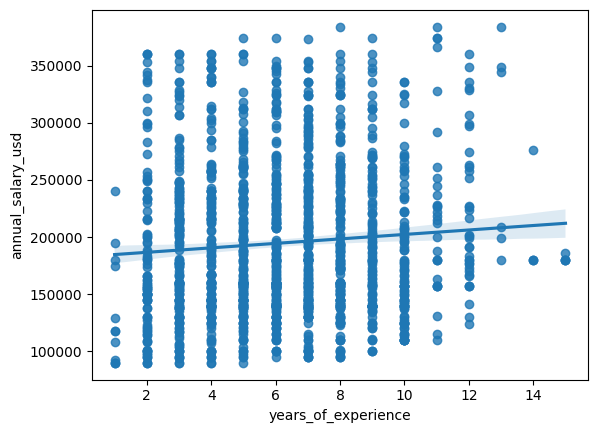

In [43]:
import seaborn as sns
sns.regplot(data=df, x="years_of_experience", y="annual_salary_usd")

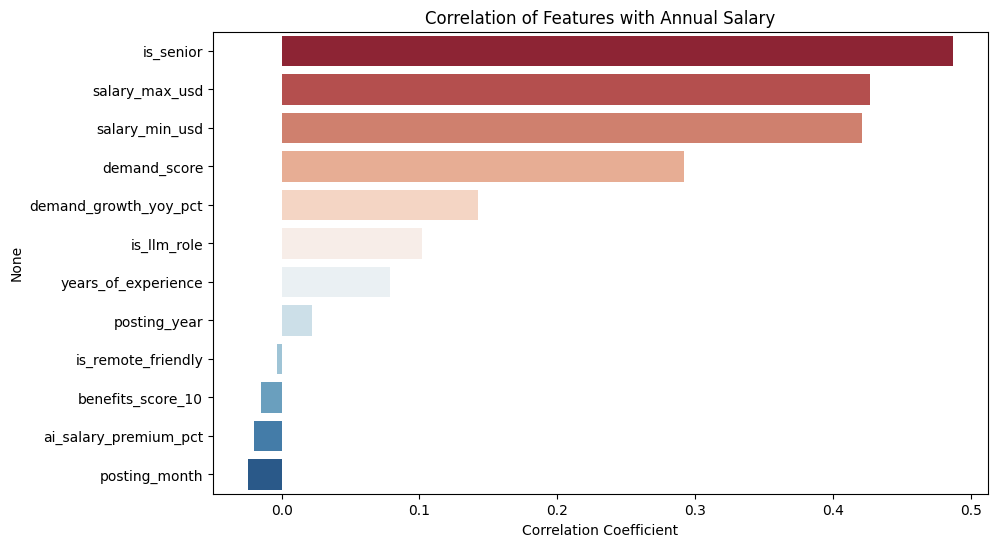

In [44]:
corr_matrix = df.corr(numeric_only=True)
salary_corr = corr_matrix["annual_salary_usd"].sort_values(ascending=False)

salary_corr = salary_corr.drop("annual_salary_usd")
# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=salary_corr.values, y=salary_corr.index, palette="RdBu")
plt.title("Correlation of Features with Annual Salary")
plt.xlabel("Correlation Coefficient")
plt.show()

### **Top 4 Strategic Insights**


* **Seniority over Tenure:** The **`is_senior`** title is the strongest predictor of high pay, proving that organizational level impacts salary more than the raw count of **`years_of_experience`**.
* **Market Dynamics:** High **`demand_score`** and **`demand_growth_yoy`** are significant price drivers, suggesting that specialized market scarcity pushes salaries higher than specific tech labels like `is_llm_role`.
* **The Premium Paradox:** The slight negative correlation for **`ai_salary_premium_pct`** indicates that while entry-level roles get the biggest *percentage* raises, the highest *total* salaries remain in established senior brackets.
* **Seasonal & Cultural Neutrality:** Factors like **`is_remote_friendly`** and **`benefits_score`** show almost zero correlation with salary, meaning you can prioritize flexibility without sacrificing your earning potential.

### Hypothesis
The most in-demand skills (highest job posting frequency) will not necessarily be the highest paying — high demand may reflect baseline/common requirements (e.g., Python, SQL) rather than scarcity, while less universal skills (e.g., Cloud, Leadership) may command a salary premium despite lower demand counts.

                 count  count_pct
skills_list                      
Python             942       62.8
SQL                452       30.1
Cloud              429       28.6
Leadership         380       25.3
Communication      378       25.2
Research           376       25.1
Agile              351       23.4
Statistics         350       23.3
Linux              320       21.3
Problem Solving    314       20.9


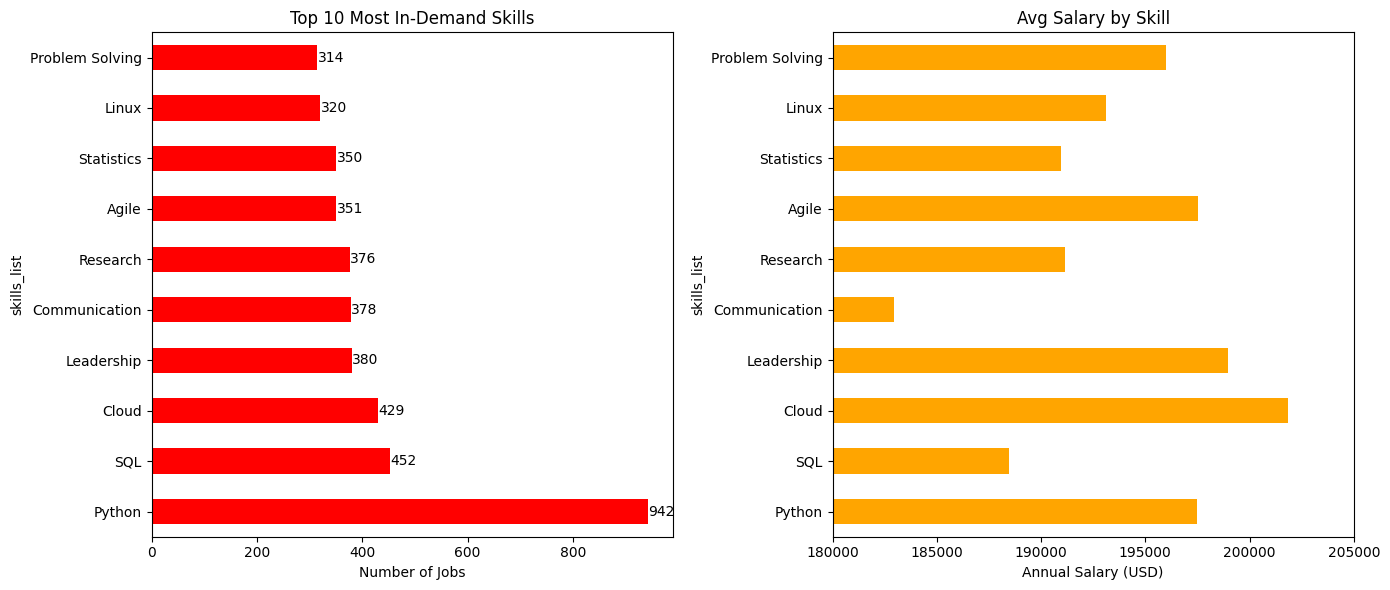

In [45]:


result = round(
    skills_exploded.groupby("skills_list")["annual_salary_usd"]
    .agg(["count", "mean"])
    .sort_values(by="count", ascending=False)
    .head(10), 2
)
result["count_pct"] = round((result["count"] / 1500) * 100, 1)
print(result[["count", "count_pct"]].sort_values(by="count", ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Most in-demand (count)
result["count"].plot(kind="barh", ax=axes[0], color="red")
axes[0].set_title("Top 10 Most In-Demand Skills")
axes[0].set_xlabel("Number of Jobs")
for i, v in enumerate(result["count"]):
    axes[0].text(v + 1, i, str(int(v)), va="center")

# Right: Avg salary per skill
result["mean"].plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Avg Salary by Skill")
axes[1].set_xlabel("Annual Salary (USD)")
axes[1].set_xlim(180000,205000)


plt.tight_layout()
plt.show()

## Key Takeway
## From Chart 1 — Top 10 Most In-Demand Skills

- **Python is the king** — 942 jobs (62.8%) making it appear in nearly 2 out of 3 job postings
- **SQL + Cloud together** cover ~59% of jobs — the core technical stack most employers expect
- **Soft skills are surprisingly common** — Communication, Leadership, Research all appear in ~25% of jobs, meaning technical skills alone aren't enough
- **The gap is massive** — Python (942) vs Problem Solving (314) is a **3x difference**, showing Python's dominance is not even close

---
## From Chart 2 — Avg Salary by Skill

- **Cloud pays the most** (~$203k) despite not being #1 in demand — **scarcity drives price**
- **Communication pays the least** (~$128k) — the only skill below $180k, confirming soft skills alone don't pay well
- **Python pays ~$197k** — high demand AND high salary makes it the single most valuable skill to learn
- **SQL is underpaid** — 2nd most required skill but near bottom in salary, suggesting it's a commodity skill
- **Leadership + Cloud + Agile** are the premium tier — all above $195k

---

## The Combined Story
> Skills split into **3 tiers:**
> - 💰 **Premium** → Cloud, Leadership, Agile ($195k+)
> - ✅ **Baseline** → Python, SQL, Statistics (required but competitive)
> - ⚠️ **Commodity** → Communication, Problem Solving (expected but don't boost salary)


### Hypothesis
Rare, specialized AI skills (e.g., System Design, Prompt Engineering, RAG) will command higher average salaries than common baseline skills, since scarcity in a fast-growing market should drive a salary premium independent of how frequently a skill is requested.

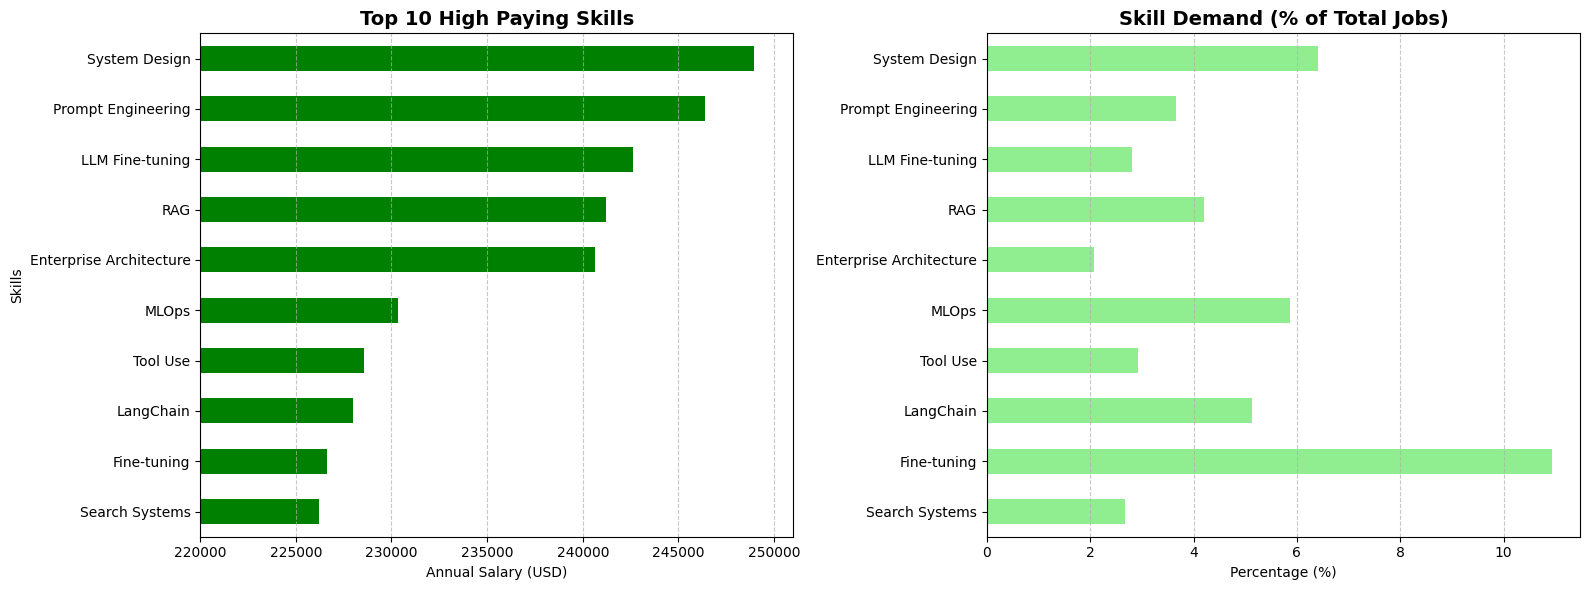

In [58]:
df["skills_list"] = df["required_skills"].str.split("|")
skills_exploded = df.explode("skills_list")

# 1. Aggregate data (Cleaned up the repetitions)
result = round(
    skills_exploded.groupby("skills_list")["annual_salary_usd"]
    .agg(["count", "mean"])
    .sort_values(by="mean", ascending=False)
    .head(10), 2
)

# Sort ascending so the highest-paying skill appears 
result_sorted = result.sort_values(by="mean", ascending=True)

# 2. Create a side-by-side layout (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left Chart: Annual Salary ---
result_sorted["mean"].plot(kind="barh", color="Green", ax=axes[0])
axes[0].set_title("Top 10 High Paying Skills", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Annual Salary (USD)")
axes[0].set_ylabel("Skills")
axes[0].set_xlim(220000, 251000)
axes[0].grid(axis='x', linestyle='--', alpha=0.7) # Adds a clean gridline

# --- Right Chart: Demand (% of Total Jobs) ---
# Calculates percentage using the same sorted order
demand_pct = (result_sorted["count"] / len(df)) * 100
demand_pct.plot(kind="barh", color="lightgreen", ax=axes[1])
axes[1].set_title("Skill Demand (% of Total Jobs)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Percentage (%)")
axes[1].set_ylabel("") # Hide y-label since it mirrors the left chart
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


## Insights — Top 10 High Paying Skills

### Key Observations

- **System Design pays the most** (~$249k) — is the most premium skill in AI jobs
- **Prompt Engineering is #2** (~$247k) — new skill already commanding near-top salaries, showing how fast the AI market values it
- **LLM Fine-tuning, RAG, Enterprise Architecture** all cluster around **$240-244k** — the core "senior AI engineer" skillset
- **Big salary gap** — top 5 skills ($240k+) vs bottom 5 skills ($222-229k) is a **~$20k difference** just from skill choice

---

### The Hidden Story — Count % Column
Looking at the percentage data below the chart:

- **Fine-tuning appears in only 10.93%** of jobs but pays ~$225k — **low demand but well paid**
- **System Design appears in only 6.4%** of jobs but pays the **most** — rarest = most expensive
- **LangChain (5.13%)** and **MLOps (5.87%)** — niche but increasingly demanded in modern AI stacks

---

### Combined Takeaway
> 💡 **Scarcity drives salary here** — the highest paying skills (System Design, Prompt Engineering, RAG) are all relatively rare in the job market. Learning these puts you in the **top salary tier ($240k+)** with less competition.


In [59]:
df.head(2)

,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier,exp_bin,skills_list
0,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k),6-9,"[APIs, Planning Systems, Python, Cloud, SQL, Leadership]"
1,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NLP|Testing|Cloud,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k),0-2,"[Python, Documentation, LLM APIs, Prompt Design, NLP, Testing, Cloud]"


### Hypothesis
Job-assigned `experience_level` will show a stronger, more consistent relationship with salary than raw `years_of_experience`, since companies likely price roles by negotiated title/band rather than tenure alone.

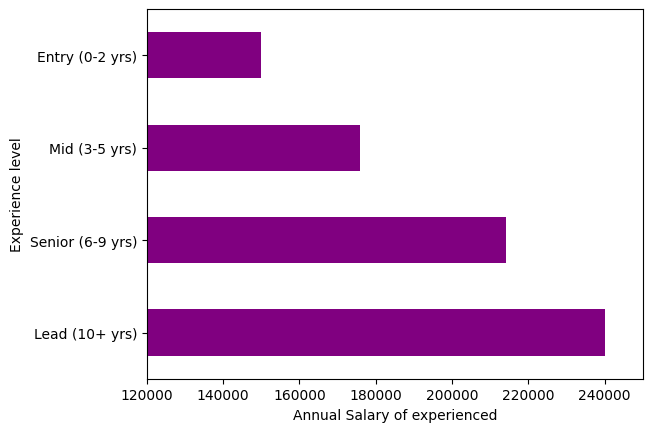

In [60]:
# Salary by experience_level (job's assigned tier) vs years_of_experience (actual tenure)
ct = df.groupby("experience_level")["annual_salary_usd"].mean().sort_values(ascending=False)
ct.plot(kind="barh",color="purple")
plt.ylabel("Experience level")
plt.xlabel("Annual Salary of experienced")
plt.xlim(120000,250000)
plt.show()


### Salary by Experience Level

The data shows a clear, consistent upward trend in salary as the assigned experience level increases:

| Experience Level | Avg. Annual Salary (USD) |
|---|---|
| Entry (0-2 yrs) | ~$150,000 |
| Mid (3-5 yrs) | ~$176,000 |
| Senior (6-9 yrs) | ~$214,000 |
| Lead (10+ yrs) | ~$240,000 |

**Key Observation:** Unlike `years_of_experience` (which plateaus and shows weak correlation with salary after year 2), `experience_level` shows a clean, near-linear progression — a **~60% salary increase** from Entry to Lead level.

This confirms that **the seniority tier a job is posted/labeled as is a far stronger salary driver than a candidate's raw years of experience.** Companies appear to pay for the assigned role level/title rather than tenure alone — reinforcing that career growth in this market is more about reaching the next *level* than simply accumulating years.

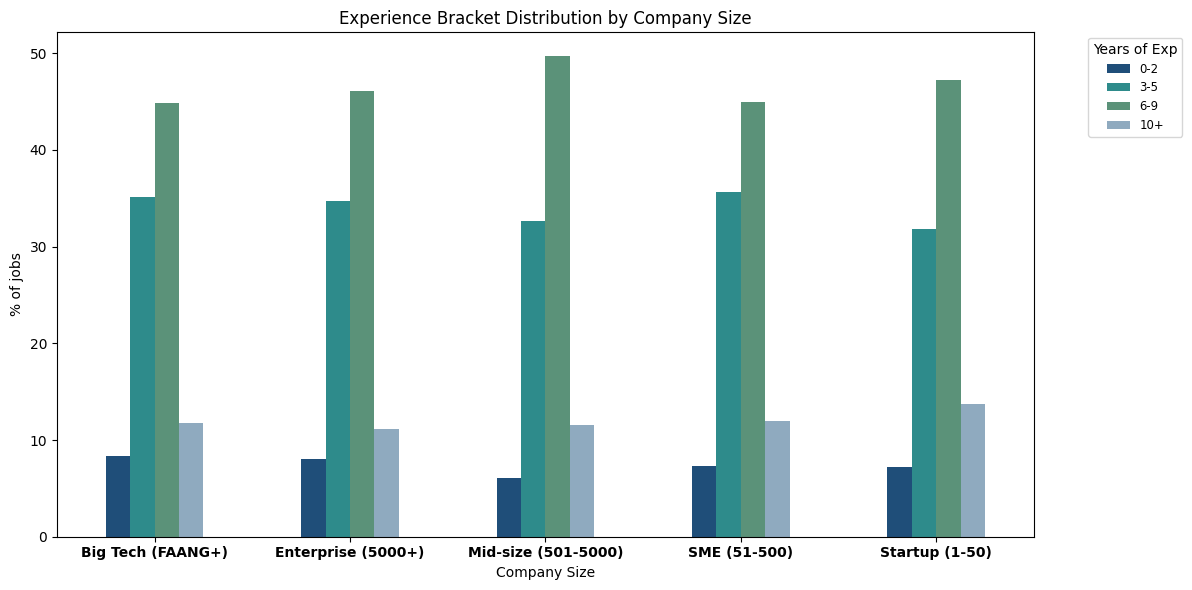

In [61]:
df["exp_bin"] = pd.cut(df["years_of_experience"], bins=[0,2,5,9,15], labels=["0-2","3-5","6-9","10+"])
ct = round(pd.crosstab(df["company_size"], df["exp_bin"], normalize="index") * 100, 2)

ct.plot(kind="bar", figsize=(12,6), color=["#1f4e79", "#2e8b8b", "#5b9279", "#8faabf"])
plt.title("Experience Bracket Distribution by Company Size")
plt.ylabel("% of jobs")
plt.xlabel("Company Size")
plt.xticks(rotation=0, fontweight="bold")
plt.legend(title="Years of Exp", bbox_to_anchor=(1.05,1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

Key Takeway

* **The 6–9 Years Dominance:** This bracket is the undisputed priority for all company sizes, commanding 45% to 50% of all job openings.
* **The Entry-Level Crunch:** Opportunities for true juniors (0–2 years) are heavily restricted, making up less than 10% of the market everywhere.
* **The Bulk of Hiring:** Mid-to-senior professionals (3–9 years) form the core of the market, accounting for roughly 75% to 80% of total demand.
* **Startup Veteran Bias:** Startups (1–50 employees) actively hunt for deep expertise, leading all categories with the highest share of 10+ year roles.
* **Mid-Size Senior Peak:** Mid-size companies (501–5000 employees) are the most aggressive hirers of the 6–9 year bracket, peaking at nearly 50%.

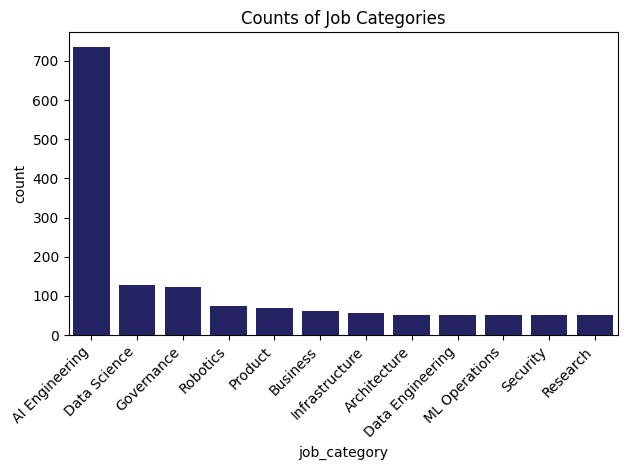

In [62]:

# Pass the original DataFrame directly to Seaborn
sns.countplot(
    data=df, 
    x="job_category", 
    color="midnightblue",
    order=df["job_category"].value_counts().index
)

plt.xticks(rotation=45, ha="right")
plt.title("Counts of Job Categories")
plt.tight_layout()
plt.show()

In [63]:
temp_df = df[df["job_category"] == "AI Engineering"]
round(temp_df.groupby("job_title")["annual_salary_usd"].mean().sort_values(ascending=False),2).head(5)

job_title
Senior ML Engineer        247953.12
LLM Engineer              240960.00
AI Agent Developer        225649.12
Multimodal AI Engineer    221791.04
RAG Engineer              218226.42
Name: annual_salary_usd, dtype: float64

In [64]:
# Temporarily converts everything to text just to count duplicates
print(df.astype(str).duplicated().sum())

0


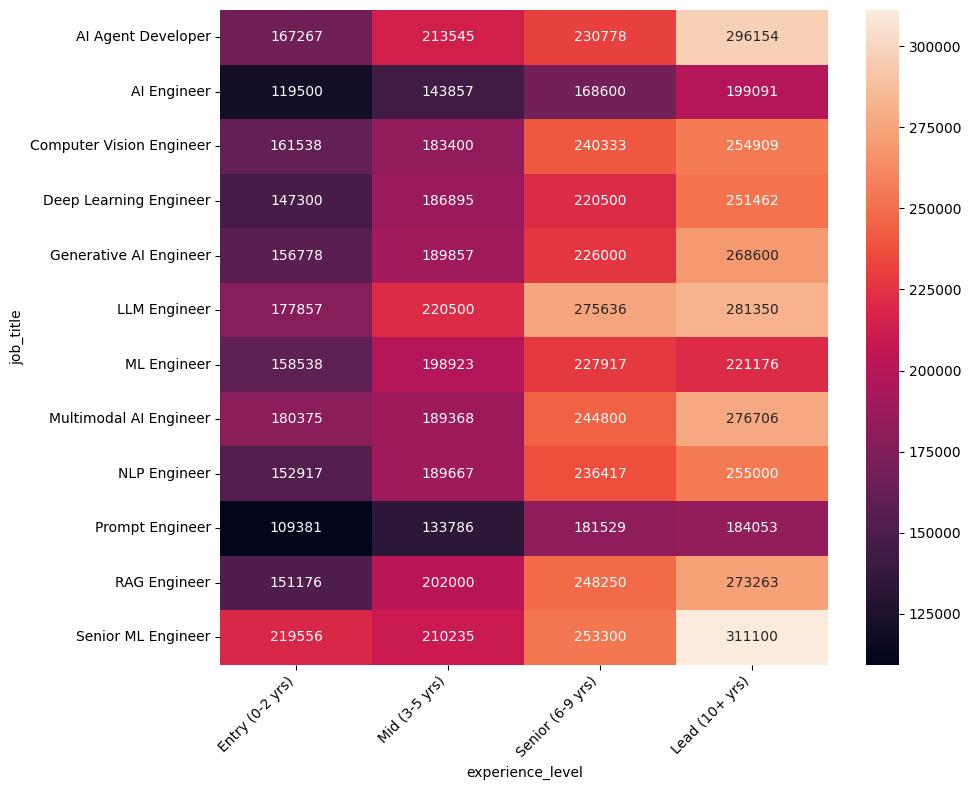

In [65]:
# Switch .pivot to .pivot_table
pivot_df = temp_df.pivot_table(
    index="job_title",
    columns="experience_level",
    values="annual_salary_usd",
    aggfunc="mean"  # It will calculate the average salary for duplicates
)
column_order = ["Entry (0-2 yrs)", "Mid (3-5 yrs)", "Senior (6-9 yrs)", "Lead (10+ yrs)"]

pivot_df = pivot_df.reindex(columns=column_order)

pivot_df = pivot_df.round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, cmap="rocket",fmt=".0f",) # format dynamically with your settings

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Here is the concise, high-impact version tailored for an executive summary or slide deck:

* **Clear Seniority Premium:** Compensation scales predictably upward across all AI domains from entry-level to lead roles.
* **Peak Market Demand:** Lead-level **Senior ML Engineers** and **AI Agent Developers** top the market at $310k and $300k.
* **Entry-Level Inversion:** Senior ML Engineers entry-level baseline begins exceptionally high ($220k) before standard mid-level normalization.
* **Lower Bound Disciplines:** **AI Engineers** and **Prompt Engineers** consistently anchor the bottom of the pay structure (~$110k–$120k entry).
* **The $250k Senior Catalyst:** Reaching Senior status (6–9 years) acts as a standard threshold to break into the $240k–$250k tier for core AI domains.

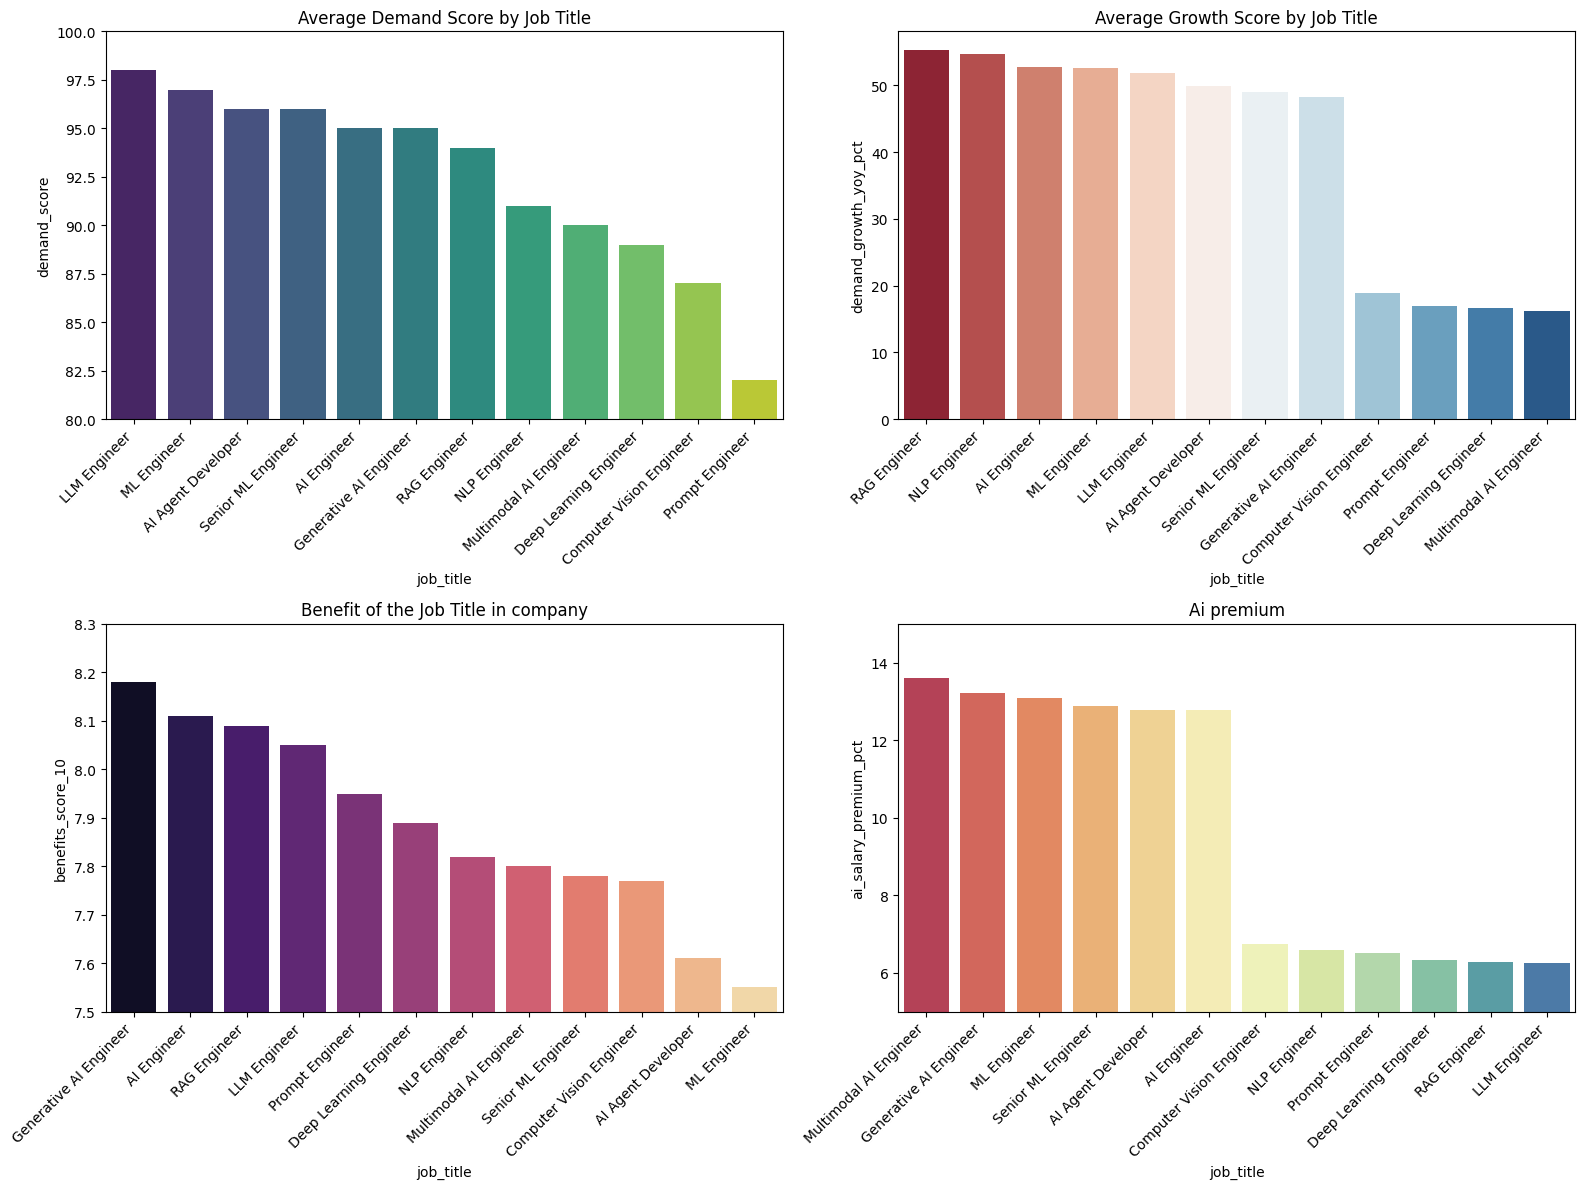

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate and sort the data
x = temp_df.groupby("job_title")[["demand_score", "demand_growth_yoy_pct", "benefits_score_10","ai_salary_premium_pct"]].mean().round(2)
x = x.sort_values(by="demand_score", ascending=False)
y = x.sort_values(by="demand_growth_yoy_pct", ascending=False)
z = x.sort_values(by="benefits_score_10", ascending=False)
a = x.sort_values(by="ai_salary_premium_pct", ascending=False)

# Create a single master figure sized perfectly for a 2x2 grid setup
plt.figure(figsize=(16, 12))

# --- LINE 1: TWO CHARTS SIDE-BY-SIDE ---

# Chart 1: Top Left
ax1 = plt.subplot(2, 2, 1)
sns.barplot(data=x, x=x.index, y="demand_score", palette="viridis", ax=ax1)
ax1.set_title("Average Demand Score by Job Title")
ax1.set_ylim(80, 100)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# Chart 2: Top Right
ax2 = plt.subplot(2, 2, 2)
sns.barplot(data=y, x=y.index, y="demand_growth_yoy_pct", palette="RdBu", ax=ax2)
ax2.set_title("Average Growth Score by Job Title")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")


# --- LINE 2: ONE WIDE CHART UNDERNEATH ---


ax3 = plt.subplot(2, 2, 3)
sns.barplot(data=z, x=z.index, y="benefits_score_10", palette="magma", ax=ax3)
ax3.set_title("Benefit of the Job Title in company")
ax3.set_ylim(7.5, 8.3)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha="right")

ax4 = plt.subplot(2, 2, 4)
sns.barplot(data=a, x=a.index, y="ai_salary_premium_pct", palette="Spectral", ax=ax4)
ax4.set_title("Ai premium")
ax4.set_ylim(5, 15)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha="right")
# Optimize spacing globally across all subplots
plt.tight_layout()
plt.show()

Based on the final multi-chart layout, here is the professional 4-line executive takeaway:

* **High Demand Stability:** Advanced backend AI specializations (**LLM Engineer** and **ML Engineer**) maintain the highest absolute market demand scores, anchoring the current hiring priority landscape.
* **Aggressive Growth Trajectory:** Despite having lower base demand, emerging niches like **RAG Engineer** and **NLP Engineer** are experiencing the most rapid year-over-year growth, showing sudden market acceleration.
* **Perks Over Pay:** Organizations are compensating lower overall demand roles like **Generative AI Engineer** and **AI Engineer** with top-tier benefits packages, ranking them highest in corporate perks.
* **The Emerging Bottleneck:** **AI Agent Developers** present a rare balanced constraint—ranking 3rd in total demand and exhibiting high growth, yet resting near the bottom for benefits, indicating a highly competitive hiring friction point.

<Axes: xlabel='education_required', ylabel='job_title'>

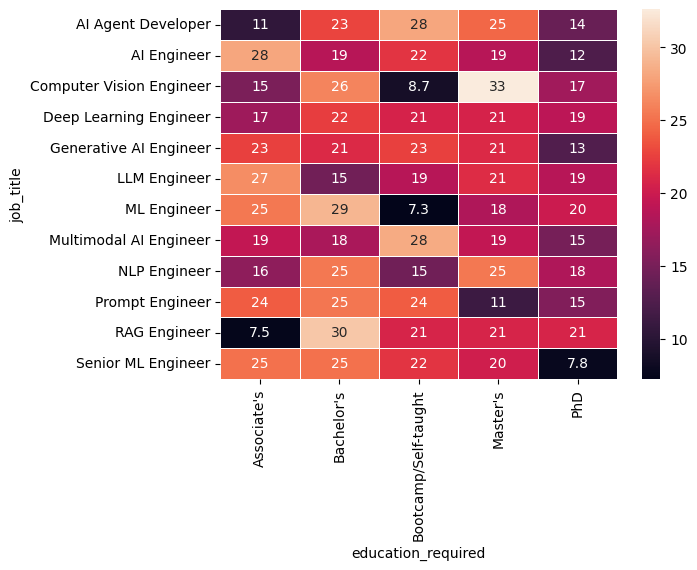

In [67]:
ct = (pd.crosstab(temp_df["job_title"],temp_df["education_required"],normalize="index")*100).round(2)
sns.heatmap(ct,annot=True,linewidths=0.5)

 executive takeaway:

* **Lower Barriers to Entry:** Traditional four-year degrees are not a strict gatekeeper across the board, as non-traditional paths like **Bootcamp/Self-taught** show robust representation—even peaking at a high concentration for AI Agent Developers (28).
* **The Advanced Degree Premium:** Roles requiring deeply specialized academic research, such as **Computer Vision Engineer**, show a heavy emphasis on higher education, spiking sharply at the Master's level (33).
* **Vulnerability of Specialized Roles to Low Education:** Advanced engineering positions like **Senior ML Engineer** and **RAG Engineer** show distinct vulnerabilities at the lowest educational thresholds, posting some of the lowest market representation scores (7.8 and 7.5) at the Associate's level.

## Data Science Jobs Analysis

In [68]:
temp_df = df[df["job_category"]  == "Data Science"]
print(temp_df["job_title"].value_counts())

pd.crosstab(temp_df["job_title"],temp_df["is_llm_role"])

job_title
Senior Data Scientist    66
Data Scientist           61
Name: count, dtype: int64


is_llm_role,0
job_title,
Data Scientist,61
Senior Data Scientist,66


Core Domain :  Surprisingly Market data reveals that traditional Data Scientist tracks remained strictly focused on statistical modeling and predictive analytics, keeping them distinct from generative AI branches.

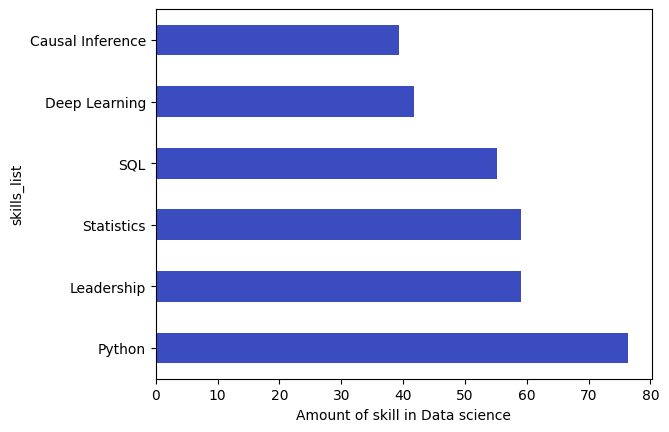

In [69]:
ct =temp_df["skills_list"].explode().str.strip().value_counts().head(6)

round(ct/len(temp_df)*100,2).plot(kind="barh",colormap="coolwarm")
plt.xlabel("Amount of skill in Data science")
plt.show()

### Key Insights: Data Science Skill Demand

* **Dominance of Core Languages:** **Python** stands out as the most critical baseline skill for Data Science, holding a massive lead over infrastructure tools like SQL and foundational analytics.
* **Balanced Methodological Stack:** Foundational execution skills (**Leadership** and **Statistics**) share equal market weight, followed closely by specialized technical capabilities like **Deep Learning** and **Causal Inference**.

<Axes: xlabel='is_remote_friendly', ylabel='count'>

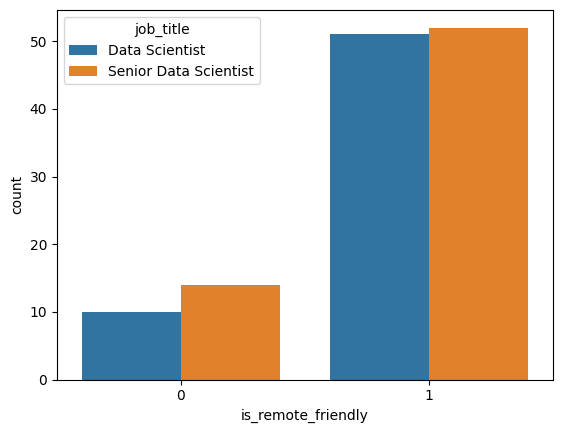

In [70]:
sns.countplot(data=temp_df,x="is_remote_friendly",hue="job_title")

##### Maximum roles of data science are remote friendly

In [71]:
# Use pivot_table and specify an aggregation function like 'mean' or 'median'
salary_pivot = temp_df.pivot_table(
    index="education_required", 
    columns="job_title", 
    values="annual_salary_usd", 
    aggfunc="mean"
).round(2)

# Display the pivoted matrix
print(salary_pivot)

job_title             Data Scientist  Senior Data Scientist
education_required                                         
Associate's                164944.44              179680.00
Bachelor's                 157727.27              171757.14
Bootcamp/Self-taught       177125.00              190383.33
Master's                   193888.89              202400.00
PhD                        181733.33              200800.00


* **Degree Tier Progression:** Salaries scale predictably with formal education, peaking at the **Master's and PhD** levels, where Senior Data Scientists break the $200,000 threshold.
* **The Bootcamp Premium:** Interestingly, **Bootcamp/Self-taught** professionals outpace Associate's and Bachelor's degree holders in average compensation, suggesting strong market value for practical, non-traditional skill sets.

#### Checking is Person Experience Level change title of job

<Axes: xlabel='years_of_experience'>

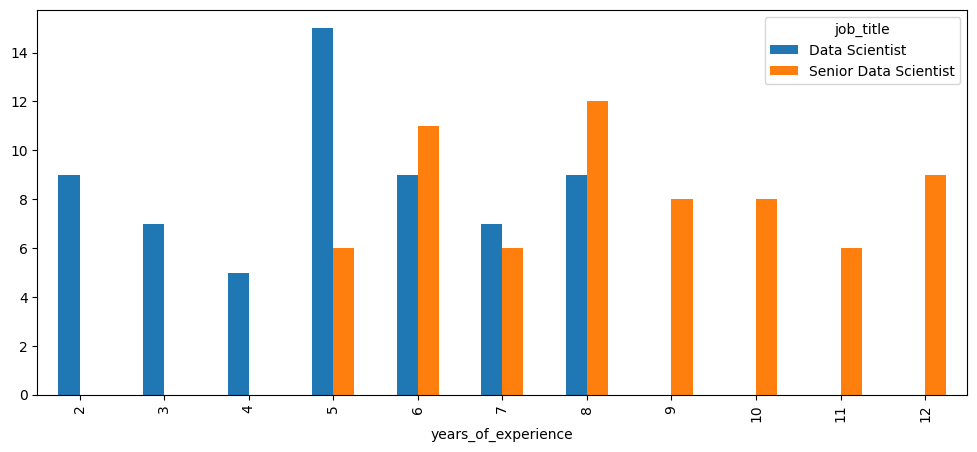

In [72]:
z = pd.crosstab(temp_df["years_of_experience"],temp_df["job_title"])
z.plot(kind="bar",figsize=(12,5))


* **Promotion Window:** The transition from Data Scientist to **Senior Data Scientist** primarily happens between **5 to 6 years** of experience.
* **Hard Cutoff:** After **8 years** of experience, the mid-level "Data Scientist" title completely disappears, meaning a Senior title is standard for anyone with 9+ years in the field.

In [73]:
round(temp_df[["ai_salary_premium_pct","demand_score","demand_growth_yoy_pct",	"benefits_score_10"]].mean(),2)

ai_salary_premium_pct     6.55
demand_score             90.96
demand_growth_yoy_pct    31.50
benefits_score_10         7.86
dtype: float64

* **Significant Financial Premium:** AI specialization yields an immediate **6.55% salary premium**, proving that upskilling directly translates into a higher baseline compensation.
* **Strong Market Demand:** The field holds an exceptional **90.96 demand score** coupled with a rapid **31.50% year-over-year growth**, indicating an aggressive and expanding hiring landscape.
* **Competitive Benefit Packages:** A high **7.86 out of 10 benefits score** reflects that companies are leveraging premium perks and robust incentives to attract and retain highly sought-after AI talent.

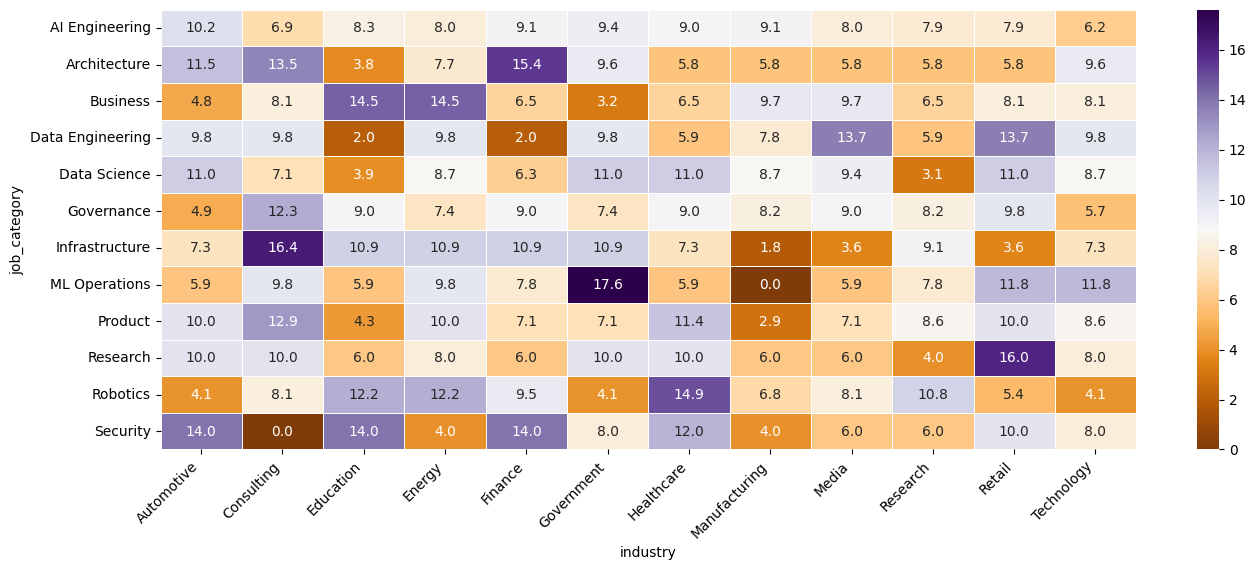

In [74]:
x = round(pd.crosstab(df["job_category"],df["industry"],normalize="index")*100,1)
plt.figure(figsize=(14,6))
sns.heatmap(x, annot=True, fmt=".1f", linewidths=0.5, cmap="PuOr")
plt.tight_layout()
plt.xticks(rotation=45, ha="right")
plt.show()

## Key Takeaways

- **ML Operations in Government** commands the highest concentration (17.6),
  making it the most lucrative combination in the dataset.

- **Architecture in Finance** (15.4) and **Infrastructure in Consulting** (16.4)
  are strong outliers — niche but high-paying intersections.

- **Research in Retail** (16.0) surprisingly outperforms many tech-adjacent roles,
  suggesting underrated demand.

- **AI Engineering** salaries are relatively consistent (6.2–10.2) across all
  industries — broad demand but no single dominant sector.

- **Data Science** pays best in **Automotive & Government** (11.0) and weakest
  in **Research** (3.1) — indicating research roles are academically driven.

- **Manufacturing** shows low compensation for ML Operations (0.0) and
  Product roles (2.9) — least attractive sector for DS/ML professionals.

- **Security roles** are strong in Automotive, Education, and Finance (14.0)
  but nearly absent in Consulting (0.0).

- For DS/ML job seekers, **Government, Finance, and Consulting**
  offer the highest role-specific salaries across most categories.

{'whiskers': [<matplotlib.lines.Line2D at 0x1a3617b73d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1a3617b6850>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a3617c3b50>],
 'medians': [<matplotlib.lines.Line2D at 0x1a36116a490>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a36116ae90>],
 'means': []}

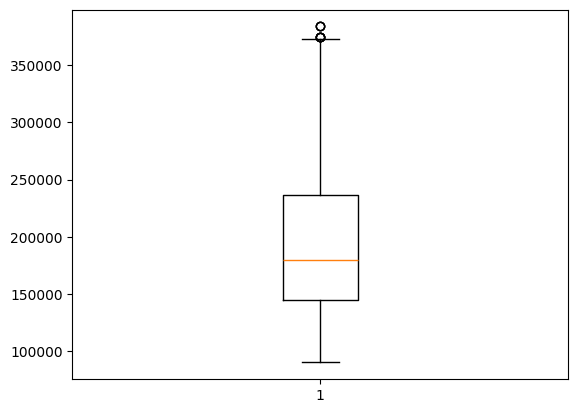

In [75]:


plt.boxplot(df["annual_salary_usd"])

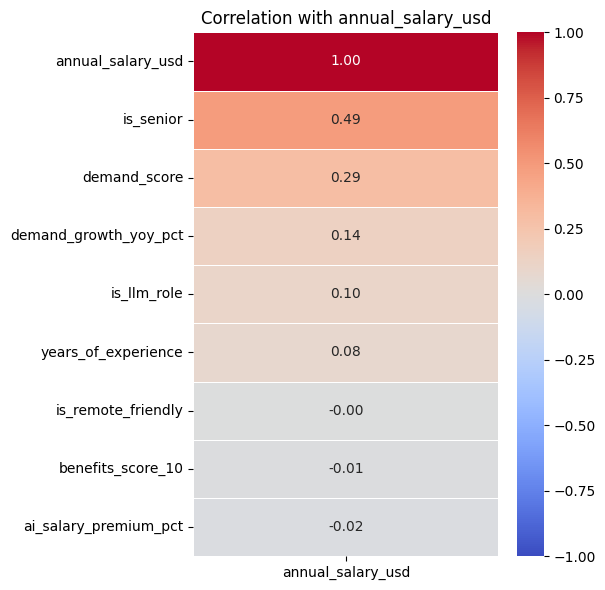

In [76]:
X_drop = ["posting_year", "posting_month", "salary_min_usd", "salary_max_usd"]

corr_series = (df.select_dtypes(include='number')
                 .drop(columns=X_drop)
                 .corr()["annual_salary_usd"]
                 .sort_values(ascending=False))

# Convert to DataFrame for heatmap — it needs 2D input
plt.figure(figsize=(6, 6))
sns.heatmap(
    corr_series.to_frame(),   # ← this is the fix: (39,) → (39,1) DataFrame
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Correlation with annual_salary_usd")
plt.tight_layout()
plt.show()

In [77]:
df.to_csv("../data/analyis_data.csv")

In [78]:
df.head(2)

,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier,exp_bin,skills_list
0,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k),6-9,"[APIs, Planning Systems, Python, Cloud, SQL, Leadership]"
1,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NLP|Testing|Cloud,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k),0-2,"[Python, Documentation, LLM APIs, Prompt Design, NLP, Testing, Cloud]"
